In [28]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [29]:
# 🚀 Hyperparams
latent_dim = 100
batch_size = 128
lr = 0.0002
epochs = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 🧽 Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),  # scale to [-1, 1]
])

In [30]:
# 📦 MNIST Dataset
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.12MB/s]


In [31]:
# 🎨 Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

# 🕵️ Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img)

In [32]:
# ⚙️ Setup
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))


🎯 Epoch 1/50 | Loss D: 1.1292 | Loss G: 0.7415


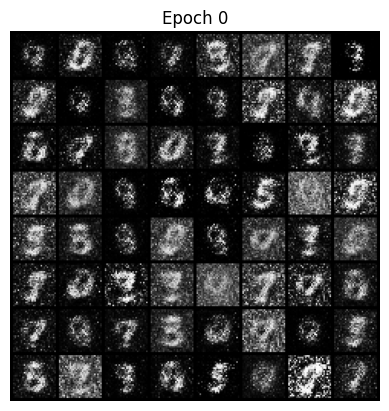

🎯 Epoch 2/50 | Loss D: 1.0868 | Loss G: 0.9293
🎯 Epoch 3/50 | Loss D: 1.5171 | Loss G: 0.6874
🎯 Epoch 4/50 | Loss D: 1.0348 | Loss G: 1.5187
🎯 Epoch 5/50 | Loss D: 1.1837 | Loss G: 2.1808
🎯 Epoch 6/50 | Loss D: 0.9701 | Loss G: 1.0907
🎯 Epoch 7/50 | Loss D: 0.9926 | Loss G: 1.0237
🎯 Epoch 8/50 | Loss D: 1.4562 | Loss G: 2.0313
🎯 Epoch 9/50 | Loss D: 1.0895 | Loss G: 1.1344
🎯 Epoch 10/50 | Loss D: 1.0878 | Loss G: 0.8574
🎯 Epoch 11/50 | Loss D: 1.0952 | Loss G: 0.9537


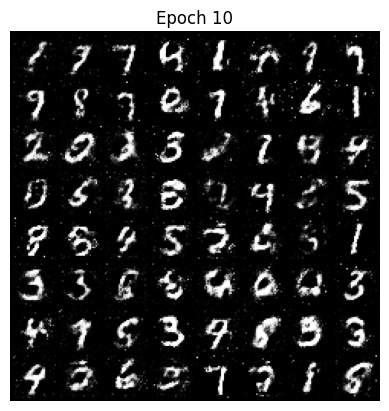

🎯 Epoch 12/50 | Loss D: 1.1162 | Loss G: 1.2712
🎯 Epoch 13/50 | Loss D: 1.1057 | Loss G: 1.2636
🎯 Epoch 14/50 | Loss D: 1.1303 | Loss G: 0.7748
🎯 Epoch 15/50 | Loss D: 1.2121 | Loss G: 0.8108
🎯 Epoch 16/50 | Loss D: 1.2700 | Loss G: 1.3442
🎯 Epoch 17/50 | Loss D: 1.2421 | Loss G: 0.9024
🎯 Epoch 18/50 | Loss D: 1.0652 | Loss G: 1.1125
🎯 Epoch 19/50 | Loss D: 1.4121 | Loss G: 0.4155
🎯 Epoch 20/50 | Loss D: 1.2183 | Loss G: 0.9163
🎯 Epoch 21/50 | Loss D: 1.2903 | Loss G: 1.3537


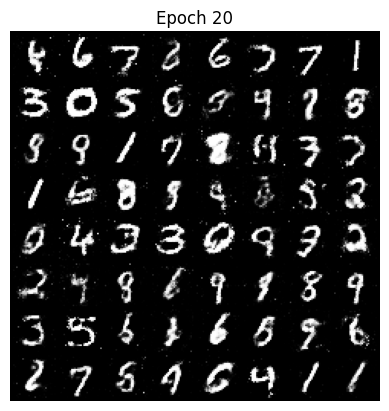

🎯 Epoch 22/50 | Loss D: 1.1489 | Loss G: 0.9299
🎯 Epoch 23/50 | Loss D: 1.2189 | Loss G: 1.1157
🎯 Epoch 24/50 | Loss D: 1.4072 | Loss G: 0.4473
🎯 Epoch 25/50 | Loss D: 1.1976 | Loss G: 0.8519
🎯 Epoch 26/50 | Loss D: 1.2474 | Loss G: 0.8619
🎯 Epoch 27/50 | Loss D: 1.2181 | Loss G: 0.8016
🎯 Epoch 28/50 | Loss D: 1.2224 | Loss G: 0.8023
🎯 Epoch 29/50 | Loss D: 1.2548 | Loss G: 0.6603
🎯 Epoch 30/50 | Loss D: 1.2022 | Loss G: 1.2358
🎯 Epoch 31/50 | Loss D: 1.2023 | Loss G: 0.6911


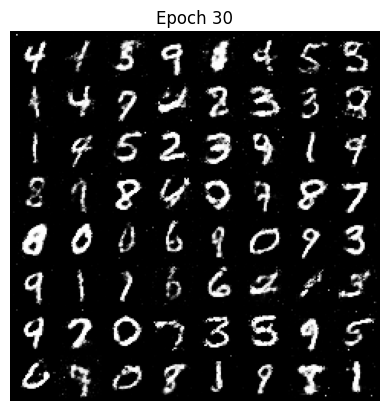

🎯 Epoch 32/50 | Loss D: 1.3081 | Loss G: 1.4820
🎯 Epoch 33/50 | Loss D: 1.1967 | Loss G: 1.3803
🎯 Epoch 34/50 | Loss D: 1.1950 | Loss G: 0.6992
🎯 Epoch 35/50 | Loss D: 1.2607 | Loss G: 1.2731
🎯 Epoch 36/50 | Loss D: 1.1780 | Loss G: 0.7720
🎯 Epoch 37/50 | Loss D: 1.1918 | Loss G: 1.2123
🎯 Epoch 38/50 | Loss D: 1.1664 | Loss G: 0.9325
🎯 Epoch 39/50 | Loss D: 1.1135 | Loss G: 1.1841
🎯 Epoch 40/50 | Loss D: 1.1656 | Loss G: 1.2076
🎯 Epoch 41/50 | Loss D: 1.2025 | Loss G: 0.8965


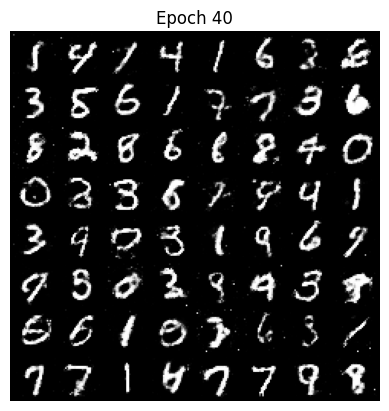

🎯 Epoch 42/50 | Loss D: 1.1555 | Loss G: 0.9767
🎯 Epoch 43/50 | Loss D: 1.2222 | Loss G: 0.9729
🎯 Epoch 44/50 | Loss D: 1.1966 | Loss G: 0.6406
🎯 Epoch 45/50 | Loss D: 1.2473 | Loss G: 0.7374
🎯 Epoch 46/50 | Loss D: 1.1419 | Loss G: 1.2839
🎯 Epoch 47/50 | Loss D: 1.1491 | Loss G: 1.0920
🎯 Epoch 48/50 | Loss D: 1.2363 | Loss G: 0.9669
🎯 Epoch 49/50 | Loss D: 1.1671 | Loss G: 0.9442
🎯 Epoch 50/50 | Loss D: 1.2914 | Loss G: 0.6366


In [33]:
# 🔁 Training Loop
for epoch in range(epochs):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # === Train Discriminator ===
        z = torch.randn(bs, latent_dim).to(device)
        fake_imgs = G(z)

        real_loss = criterion(D(real_imgs), torch.ones(bs, 1).to(device))
        fake_loss = criterion(D(fake_imgs.detach()), torch.zeros(bs, 1).to(device))
        loss_D = real_loss + fake_loss

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # === Train Generator ===
        output = D(fake_imgs)
        loss_G = criterion(output, torch.ones(bs, 1).to(device))  # wants to fool D

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"🎯 Epoch {epoch+1}/{epochs} | Loss D: {loss_D:.4f} | Loss G: {loss_G:.4f}")

    # 🖼️ Visualize every 10 epochs
    if epoch % 10 == 0:
        with torch.no_grad():
            test_z = torch.randn(64, latent_dim).to(device)
            fake_samples = G(test_z).cpu()
        grid = torchvision.utils.make_grid(fake_samples, nrow=8, normalize=True)
        plt.imshow(grid.permute(1, 2, 0))
        plt.title(f"Epoch {epoch}")
        plt.axis("off")
        plt.show()
